In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/CS2441/patches.zip -d /content/

print("Patches unzipped successfully!")

import os

folders = [
    "/content/patches/water/rgb",
    "/content/patches/water/mask",
    "/content/patches/no_water/rgb",
    "/content/patches/no_water/mask"
]

for folder in folders:
    status = "YES" if os.path.isdir(folder) else "NOT FOUND"
    print(f"   {status}  {folder}")

Patches unzipped successfully!
   YES  /content/patches/water/rgb
   YES  /content/patches/water/mask
   YES  /content/patches/no_water/rgb
   YES  /content/patches/no_water/mask


In [ ]:
import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score,
    jaccard_score,
    f1_score,
    precision_score,
    recall_score
)

from tqdm import tqdm
print(" All Libraries imported sucessfully")
print(f"PyTorch Version : {torch.__version__}")
print(f"GPU Available : {torch.cuda.is_available()}")
print(f"GPU Name : {torch.cuda.get_device_name(0)}")

 All Libraries imported sucessfully
PyTorch Version : 2.11.0+cu128
GPU Available : True
GPU Name : Tesla T4


In [ ]:
DEVICE = torch.device("cuda")

BASE_DIR         = "/content/patches"

WATER_RGB_DIR    = os.path.join(BASE_DIR, "water",    "rgb")
WATER_MASK_DIR   = os.path.join(BASE_DIR, "water",    "mask")
NOWATER_RGB_DIR  = os.path.join(BASE_DIR, "no_water", "rgb")
NOWATER_MASK_DIR = os.path.join(BASE_DIR, "no_water", "mask")

OUTPUT_DIR       = "/content/unet_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PATCH_SIZE   = 128
NUM_CHANNELS = 3

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

BATCH_SIZE    = 16
NUM_EPOCHS    = 25
LEARNING_RATE = 1e-4

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

print("Configuration set!")
print(f"   Device         : {DEVICE}")
print(f"   Batch size     : {BATCH_SIZE}")
print(f"   Epochs         : {NUM_EPOCHS}")
print(f"   Learning rate  : {LEARNING_RATE}")
print(f"   Output folder  : {OUTPUT_DIR}")
print()
print("Checking patch folders...")
for name, path in [("water/rgb",     WATER_RGB_DIR),
                   ("water/mask",    WATER_MASK_DIR),
                   ("no_water/rgb",  NOWATER_RGB_DIR),
                   ("no_water/mask", NOWATER_MASK_DIR)]:
    status = "YES" if os.path.isdir(path) else "NOT FOUND"
    print(f"   {status}  {name}")

Configuration set!
   Device         : cuda
   Batch size     : 16
   Epochs         : 25
   Learning rate  : 0.0001
   Output folder  : /content/unet_output

Checking patch folders...
   YES  water/rgb
   YES  water/mask
   YES  no_water/rgb
   YES  no_water/mask


In [ ]:
water_rgb_files    = sorted(glob.glob(os.path.join(WATER_RGB_DIR,    "*.png")))
water_mask_files   = sorted(glob.glob(os.path.join(WATER_MASK_DIR,   "*.png")))
nowater_rgb_files  = sorted(glob.glob(os.path.join(NOWATER_RGB_DIR,  "*.png")))
nowater_mask_files = sorted(glob.glob(os.path.join(NOWATER_MASK_DIR, "*.png")))

print(f"Files collected!")
print(f"   Water RGB patches     : {len(water_rgb_files)}")
print(f"   Water Mask patches    : {len(water_mask_files)}")
print(f"   No-Water RGB patches  : {len(nowater_rgb_files)}")
print(f"   No-Water Mask patches : {len(nowater_mask_files)}")

Files collected!
   Water RGB patches     : 3651
   Water Mask patches    : 3651
   No-Water RGB patches  : 3574
   No-Water Mask patches : 3574


In [ ]:
all_rgb   = water_rgb_files   + nowater_rgb_files
all_masks = water_mask_files  + nowater_mask_files

combined = list(zip(all_rgb, all_masks))
random.shuffle(combined)
all_rgb, all_masks = zip(*combined)
all_rgb   = list(all_rgb)
all_masks = list(all_masks)

print(f"Data combined and shuffled!")
print(f"   Total pairs : {len(all_rgb)}")

Data combined and shuffled!
   Total pairs : 7225


In [ ]:
n_total = len(all_rgb)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

train_rgb   = all_rgb[:n_train]
train_masks = all_masks[:n_train]

val_rgb     = all_rgb[n_train : n_train + n_val]
val_masks   = all_masks[n_train : n_train + n_val]

test_rgb    = all_rgb[n_train + n_val:]
test_masks  = all_masks[n_train + n_val:]

print(f"Data split done!")
print(f"   Total : {n_total}")
print(f"   Train : {n_train}  ({TRAIN_RATIO*100:.0f}%)")
print(f"   Val   : {n_val}    ({VAL_RATIO*100:.0f}%)")
print(f"   Test  : {n_test}   ({TEST_RATIO*100:.0f}%)")

Data split done!
   Total : 7225
   Train : 5057  (70%)
   Val   : 1083    (15%)
   Test  : 1085   (15%)


In [ ]:
class WaterPatchDataset(Dataset):

    def __init__(self, image_paths, mask_paths, augment=False):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.augment     = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img  = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        if self.augment:
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.FLIP_LEFT_RIGHT)
            if random.random() > 0.5:
                img  = img.transpose(Image.FLIP_TOP_BOTTOM)
                mask = mask.transpose(Image.FLIP_TOP_BOTTOM)
            if random.random() > 0.5:
                angle = random.choice([90, 180, 270])
                img   = img.rotate(angle)
                mask  = mask.rotate(angle)

        img  = np.array(img,  dtype=np.float32) / 255.0
        img  = torch.from_numpy(img).permute(2, 0, 1)

        mask = np.array(mask, dtype=np.float32)
        mask = (mask > 127).astype(np.float32)
        mask = torch.from_numpy(mask).unsqueeze(0)

        return img, mask

print("WaterPatchDataset class defined!")
print("   Image tensor shape : (3, 128, 128)")
print("   Mask tensor shape  : (1, 128, 128)")

WaterPatchDataset class defined!
   Image tensor shape : (3, 128, 128)
   Mask tensor shape  : (1, 128, 128)


In [ ]:
train_dataset = WaterPatchDataset(train_rgb,  train_masks, augment=True)
val_dataset   = WaterPatchDataset(val_rgb,    val_masks,   augment=False)
test_dataset  = WaterPatchDataset(test_rgb,   test_masks,  augment=False)

print("Datasets created!")
print(f"   Train dataset : {len(train_dataset)} patches")
print(f"   Val dataset   : {len(val_dataset)} patches")
print(f"   Test dataset  : {len(test_dataset)} patches")

Datasets created!
   Train dataset : 5057 patches
   Val dataset   : 1083 patches
   Test dataset  : 1085 patches


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders created!")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

DataLoaders created!
   Train batches : 317
   Val batches   : 68
   Test batches  : 68


In [ ]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = self.double_conv(3,   64)
        self.enc2 = self.double_conv(64,  128)
        self.enc3 = self.double_conv(128, 256)
        self.enc4 = self.double_conv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = self.double_conv(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.double_conv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.double_conv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.double_conv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.double_conv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)

print("UNet architecture defined!")

UNet architecture defined!


In [ ]:
class DiceBCELoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, masks):

        bce = F.binary_cross_entropy_with_logits(logits, masks)

        probs        = torch.sigmoid(logits)
        intersection = (probs * masks).sum()
        dice = 1 - (2 * intersection + 1e-7) / (probs.sum() + masks.sum() + 1e-7)

        return bce + dice

print("DiceBCELoss defined!")

DiceBCELoss defined!


In [ ]:
model     = UNet().to(DEVICE)

criterion = DiceBCELoss()

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Model ready!")
print(f"   Model     : UNet")
print(f"   Loss      : DiceBCELoss")
print(f"   Optimiser : Adam")
print(f"   LR        : {LEARNING_RATE}")

total_params = sum(p.numel() for p in model.parameters())
print(f"   Parameters: {total_params:,}")

Model ready!
   Model     : UNet
   Loss      : DiceBCELoss
   Optimiser : Adam
   LR        : 0.0001
   Parameters: 31,031,745


In [ ]:
history = {"train_loss": [], "train_dice": [],
           "val_loss":   [], "val_dice":   []}

best_val_dice   = 0.0
best_model_path = os.path.join(OUTPUT_DIR, "best_unet.pth")

print("Training started!")
print(f"   Epochs     : {NUM_EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")
print("-" * 60)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    train_loss = 0.0
    train_dice = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [Train]"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        probs        = torch.sigmoid(logits).detach()
        preds        = (probs > 0.5).float()
        intersection = (preds * masks).sum()
        dice         = (2 * intersection + 1e-7) / (preds.sum() + masks.sum() + 1e-7)

        train_loss += loss.item()
        train_dice += dice.item()

    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)

            logits = model(images)
            loss   = criterion(logits, masks)

            probs        = torch.sigmoid(logits)
            preds        = (probs > 0.5).float()
            intersection = (preds * masks).sum()
            dice         = (2 * intersection + 1e-7) / (preds.sum() + masks.sum() + 1e-7)

            val_loss += loss.item()
            val_dice += dice.item()

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)
    val_loss   /= len(val_loader)
    val_dice   /= len(val_loader)

    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_model_path)
        saved = "saved"
    else:
        saved = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} {saved}")

Training started!
   Epochs     : 25
   Batch size : 16
------------------------------------------------------------


Epoch 1/25 [Train]: 100%|██████████| 317/317 [01:05<00:00,  4.81it/s]


Epoch 01/25 | Train Loss: 0.8434 | Train Dice: 0.2099 | Val Loss: 0.7343 | Val Dice: 0.3980 saved


Epoch 2/25 [Train]: 100%|██████████| 317/317 [01:07<00:00,  4.71it/s]


Epoch 02/25 | Train Loss: 0.5952 | Train Dice: 0.4884 | Val Loss: 0.5811 | Val Dice: 0.4993 saved


...

Epoch 23/25 | Train Loss: 0.3884 | Train Dice: 0.6659 | Val Loss: 0.4692 | Val Dice: 0.5907 


Epoch 24/25 [Train]: 100%|██████████| 317/317 [01:12<00:00,  4.39it/s]


Epoch 24/25 | Train Loss: 0.3775 | Train Dice: 0.6739 | Val Loss: 0.3381 | Val Dice: 0.7084 saved


Epoch 25/25 [Train]: 100%|██████████| 317/317 [01:11<00:00,  4.41it/s]


Epoch 25/25 | Train Loss: 0.3594 | Train Dice: 0.6875 | Val Loss: 0.8948 | Val Dice: 0.3484 


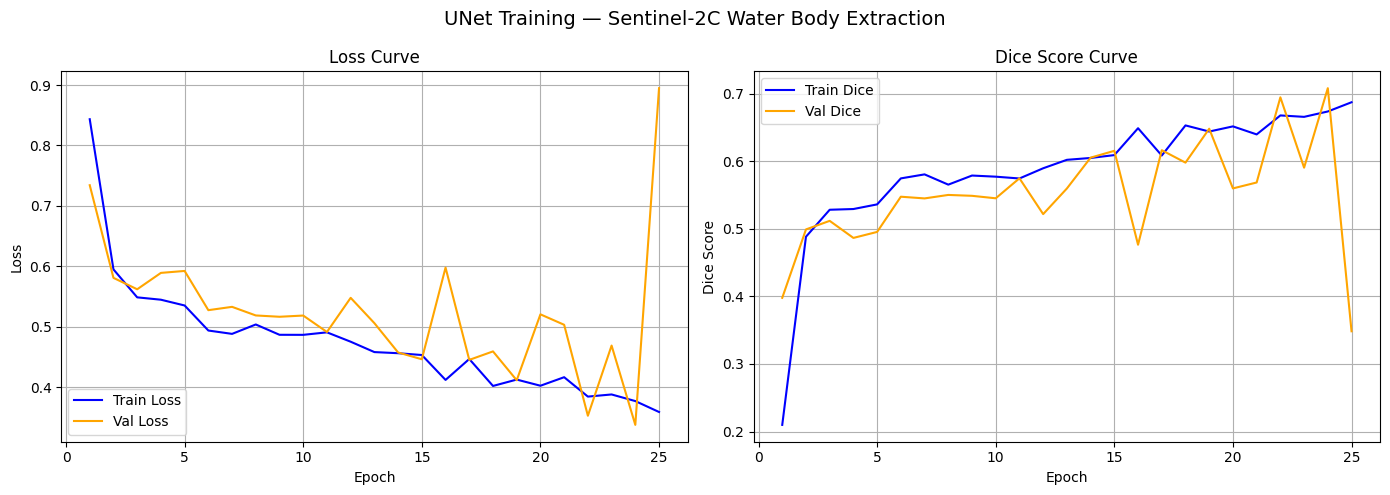

Training curves saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="blue")
axes[0].plot(epochs, history["val_loss"],   label="Val Loss",   color="orange")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, history["train_dice"], label="Train Dice", color="blue")
axes[1].plot(epochs, history["val_dice"],   label="Val Dice",   color="orange")
axes[1].set_title("Dice Score Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Score")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("UNet Training — Sentinel-2C Water Body Extraction", fontsize=14)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Training curves saved!")

In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

print("Best model loaded!")
print(f"   From : {best_model_path}")
print()

all_preds = []
all_masks = []

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_masks.append(masks.cpu())

all_preds = torch.cat(all_preds).numpy().flatten()
all_masks = torch.cat(all_masks).numpy().flatten()

all_preds_int = all_preds.astype(int)
all_masks_int = all_masks.astype(int)

accuracy  = accuracy_score(all_masks_int,  all_preds_int)
dice      = f1_score(all_masks_int,        all_preds_int)
iou       = jaccard_score(all_masks_int,   all_preds_int)
precision = precision_score(all_masks_int, all_preds_int)
recall    = recall_score(all_masks_int,    all_preds_int)

print("Test Results")
print("-" * 40)
print(f"   Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   Dice      : {dice:.4f}  ({dice*100:.2f}%)")
print(f"   IoU       : {iou:.4f}  ({iou*100:.2f}%)")
print(f"   Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   Recall    : {recall:.4f}  ({recall*100:.2f}%)")

Best model loaded!
   From : /content/unet_output/best_unet.pth



Testing: 100%|██████████| 68/68 [00:05<00:00, 11.91it/s]


Test Results
----------------------------------------
   Accuracy  : 0.9927  (99.27%)
   Dice      : 0.8663  (86.63%)
   IoU       : 0.7641  (76.41%)
   Precision : 0.8809  (88.09%)
   Recall    : 0.8522  (85.22%)


In [ ]:
water_test_samples = []

for images, masks in test_loader:
    for i in range(images.shape[0]):
        mask = masks[i].squeeze().numpy()
        water_ratio = mask.sum() / (128 * 128)

        if water_ratio > 0.10:
            water_test_samples.append((images[i], masks[i]))

    if len(water_test_samples) >= 20:
        break

print(f"Water patches found : {len(water_test_samples)}")
print(f"   Each patch has >10% water pixels")

Water patches found : 20
   Each patch has >10% water pixels


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


class GradCAM:

    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.forward_handle = target_layer.register_forward_hook(
            self.save_activations
        )
        self.backward_handle = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, input, output):
        self.activations = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor):
        self.model.eval()

        logits = self.model(input_tensor)
        probs = torch.sigmoid(logits)


        pred_mask = (probs > 0.5).float()

        if pred_mask.sum() > 0:
            score = (probs * pred_mask).sum() / (pred_mask.sum() + 1e-8)
        else:
            score = probs.mean()

        self.model.zero_grad()
        score.backward(retain_graph=True)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam

    def remove_hooks(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


print("Final Grad-CAM class ready!")

Final Grad-CAM class ready!


In [ ]:
gradcam_dir = os.path.join(OUTPUT_DIR, "gradcam")
os.makedirs(gradcam_dir, exist_ok=True)


gradcam = GradCAM(model, model.dec2)


good_samples = []

for image, mask in water_test_samples:
    mask_np = mask.squeeze().numpy()
    water_ratio = (mask_np > 0.5).sum() / (128 * 128)

    if water_ratio > 0.20:
        good_samples.append((image, mask))

print(f"Good water samples found : {len(good_samples)}")
print("Each selected patch has more than 20% water pixels")
print(f"Saving Grad-CAM images to : {gradcam_dir}")
print()

for count, (image, mask) in enumerate(good_samples[:20]):

    img_tensor = image.unsqueeze(0).to(DEVICE)
    mask_numpy = mask.squeeze().numpy()

    with torch.no_grad():
        logits = model(img_tensor)
        probs = torch.sigmoid(logits)
        pred_tensor = (probs > 0.5).float()
        pred_numpy = pred_tensor.squeeze().cpu().numpy()

    cam = gradcam.generate(img_tensor)


    rgb = image.permute(1, 2, 0).cpu().numpy()
    rgb = np.clip(rgb, 0, 1)


    rgb_vis = rgb.copy()

    for c in range(3):
        p2 = np.percentile(rgb_vis[:, :, c], 2)
        p98 = np.percentile(rgb_vis[:, :, c], 98)
        rgb_vis[:, :, c] = np.clip(
            (rgb_vis[:, :, c] - p2) / (p98 - p2 + 1e-8),
            0,
            1
        )


    predicted_water_region = pred_numpy > 0.5
    cam_water_only = np.ma.masked_where(~predicted_water_region, cam)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.patch.set_facecolor("white")


    axes[0].imshow(rgb_vis)
    axes[0].set_title("Input Image", fontsize=12, fontweight="bold")
    axes[0].axis("off")


    axes[1].imshow(mask_numpy, cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("Actual Water Mask", fontsize=12, fontweight="bold")
    axes[1].axis("off")


    axes[2].imshow(rgb_vis)
    heatmap = axes[2].imshow(
        cam_water_only,
        cmap="jet",
        alpha=0.80,
        vmin=0,
        vmax=1
    )
    axes[2].set_title("Grad-CAM on Predicted Water", fontsize=12, fontweight="bold")
    axes[2].axis("off")

    cbar = plt.colorbar(heatmap, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_label(
        "Importance: Blue low, Red high",
        rotation=270,
        labelpad=15,
        fontsize=9
    )


    axes[3].imshow(pred_numpy, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Predicted Water Mask (>0.5)", fontsize=12, fontweight="bold")
    axes[3].axis("off")

    plt.suptitle(
        f"UNet Grad-CAM - Sentinel-2C | Sample {count + 1:02d}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    save_path = os.path.join(gradcam_dir, f"gradcam_{count + 1:02d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close()

print(f"Grad-CAM images saved: {min(len(good_samples), 20)}")
print(f"Location: {gradcam_dir}")

gradcam.remove_hooks()

Good water samples found : 15
Each selected patch has more than 20% water pixels
Saving Grad-CAM images to : /content/unet_output/gradcam

Grad-CAM images saved: 15
Location: /content/unet_output/gradcam


In [ ]:
import shutil

src = "/content/unet_output/gradcam"
dst = "/content/drive/MyDrive/CS2441/unet_output/gradcam"

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)

print("Grad-CAM images saved to Drive!")
print(f"   Location : {dst}")

Grad-CAM images saved to Drive!
   Location : /content/drive/MyDrive/CS2441/unet_output/gradcam


In [ ]:
print(f"Model device : {next(model.parameters()).device}")
print(f"Model status : Ready ✅")

Model device : cuda:0
Model status : Ready ✅


In [ ]:
image, mask = water_test_samples[5]

rgb = image.permute(1, 2, 0).numpy()
print(f"Image min  : {rgb.min():.3f}")
print(f"Image max  : {rgb.max():.3f}")
print(f"Image mean : {rgb.mean():.3f}")
print(f"Mask unique values : {np.unique(mask.numpy())}")

Image min  : 0.290
Image max  : 1.000
Image mean : 0.616
Mask unique values : [0. 1.]


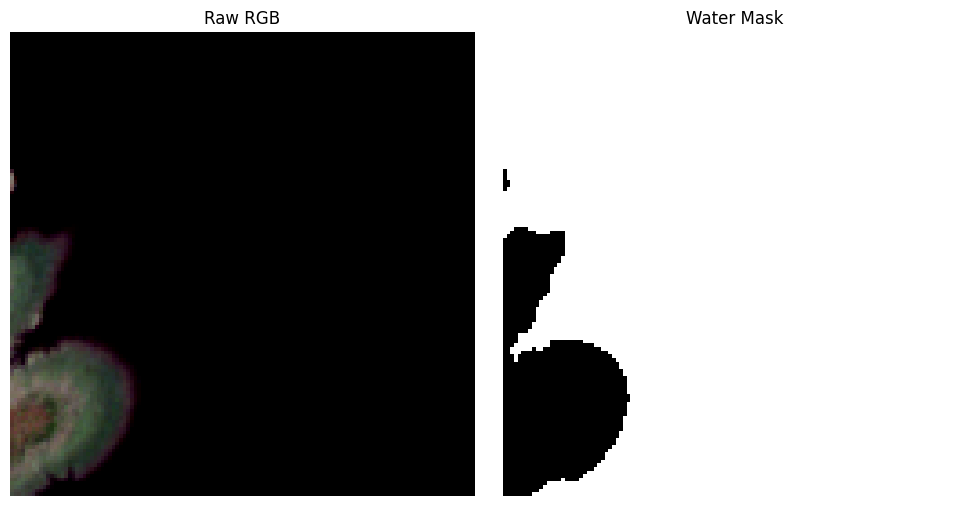

RGB  min/max : 0.000 / 0.510
Mask unique  : [0. 1.]
Water area   : 90.4% of patch


In [ ]:
image, mask = water_test_samples[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

rgb = image.permute(1, 2, 0).numpy()
axes[0].imshow(np.clip(rgb, 0, 1))
axes[0].set_title("Raw RGB")
axes[0].axis("off")

axes[1].imshow(mask.squeeze().numpy(), cmap="gray")
axes[1].set_title("Water Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"RGB  min/max : {rgb.min():.3f} / {rgb.max():.3f}")
print(f"Mask unique  : {np.unique(mask.numpy())}")
water_percent = mask.numpy().sum() / (128*128) * 100
print(f"Water area   : {water_percent:.1f}% of patch")

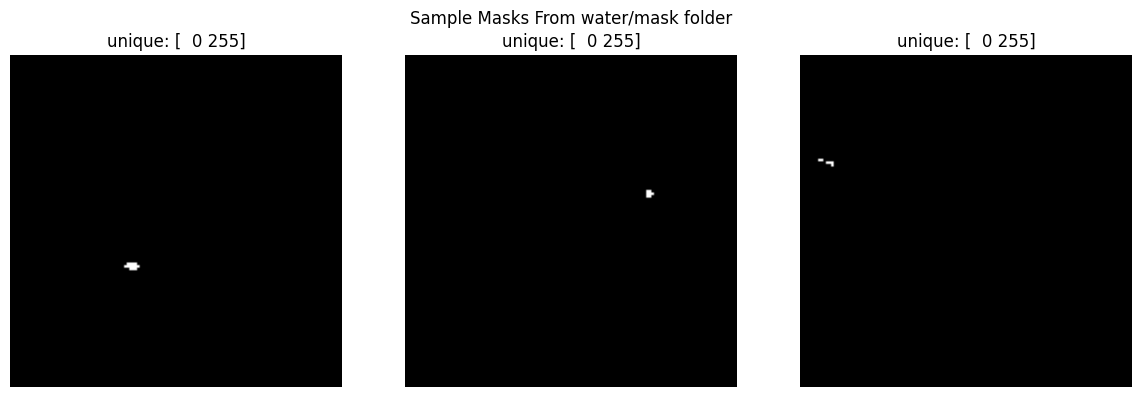

In [ ]:
import glob

mask_files = sorted(glob.glob(
    "/content/patches/water/mask/*.png"))[:3]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, path in enumerate(mask_files):
    mask_img = np.array(Image.open(path).convert("L"))
    axes[i].imshow(mask_img, cmap="gray")
    axes[i].set_title(f"unique: {np.unique(mask_img)}")
    axes[i].axis("off")

plt.suptitle("Sample Masks From water/mask folder")
plt.tight_layout()
plt.show()